In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import time
from keras.layers import Flatten, Dense, Conv2D, MaxPooling2D, Input
from keras.models import Sequential

In [ ]:
t = time.time()

In [ ]:
#Tensorflow datasets tiene error al descargar el set de perros y gatos y lo solucionaron
#el 16 de mayo pero sigue fallando en los colabs. Entonces se agrega esta linea adicional
#Mas detalle aqui: https://github.com/tensorflow/datasets/issues/3918
setattr(tfds.image_classification.cats_vs_dogs, '_URL',"https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip")

In [ ]:
#Descargar el set de datos de perros y gatos
datos, metadatos = tfds.load('cats_vs_dogs', as_supervised=True, with_info=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/23262 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.UNR7DQ_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.


In [ ]:
metadatos

tfds.core.DatasetInfo(
    name='cats_vs_dogs',
    full_name='cats_vs_dogs/4.0.1',
    description="""
    A large set of images of cats and dogs. There are 1738 corrupted images that are dropped.
    """,
    homepage='https://www.microsoft.com/en-us/download/details.aspx?id=54765',
    data_dir=PosixGPath('/tmp/tmpf3wwxew_tfds'),
    file_format=tfrecord,
    download_size=786.67 MiB,
    dataset_size=1.04 GiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'image/filename': Text(shape=(), dtype=string),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    splits={
        'train': <SplitInfo num_examples=23262, num_shards=16>,
    },
    citation="""@Inproceedings (Conference){asirra-a-captcha-that-exploits-interest-aligned-manual-image-categorization,
    author = {Elson, Jeremy and Douceur, John (JD) and Howell, Jon and Saul, Jared},
    

### Mostrando los datos

,image,label
0,,1 (dog)
1,,1 (dog)
2,,1 (dog)
3,,0 (cat)
4,,1 (dog)

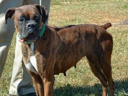
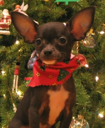
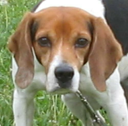
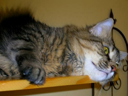
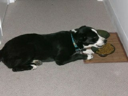

In [ ]:
#Una forma de mostrar 5 ejemplos del set
tfds.as_dataframe(datos['train'].take(5), metadatos)

(262, 350, 3)


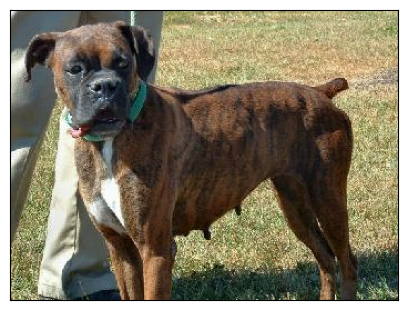

In [ ]:
# visualizar el set

import matplotlib.pyplot as plt
import cv2

plt.figure(figsize=(5,5))

for i, (imagen, etiqueta) in enumerate(datos['train'].take(1)):
  plt.xticks([])
  plt.yticks([])
  plt.imshow(imagen)
  print(imagen.shape)

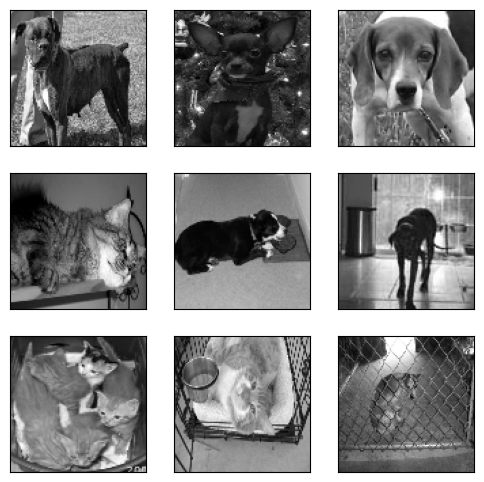

In [ ]:
#Manipular y visualizar el set
#Lo pasamos a TAMANO_IMG (100x100) y a blanco y negro (solo para visualizar)
import matplotlib.pyplot as plt
import cv2

plt.figure(figsize=(6,6))

TAMANO_IMG=100

for i, (imagen, etiqueta) in enumerate(datos['train'].take(9)):
  imagen = cv2.resize(imagen.numpy(), (TAMANO_IMG, TAMANO_IMG))
  imagen = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
  plt.subplot(3, 3, i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(imagen, cmap='gray')

In [ ]:
#Variable que contendra todos los pares de los datos (imagen y etiqueta) ya modificados (blanco y negro, 100x100)
datos_entrenamiento = []

In [ ]:
for i, (imagen, etiqueta) in enumerate(datos['train']): #Todos los datos
  imagen = cv2.resize(imagen.numpy(), (TAMANO_IMG, TAMANO_IMG))
  imagen = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)

  imagen = imagen.reshape(TAMANO_IMG, TAMANO_IMG, 1) #Cambiar tamano a 100,100,1

  datos_entrenamiento.append([imagen, etiqueta])

In [ ]:
#Preparar mis variables X (entradas) y y (etiquetas) separadas

X = [] #imagenes de entrada (pixeles)
y = [] #etiquetas (perro o gato)

for imagen, etiqueta in datos_entrenamiento:
  X.append(imagen)
  y.append(etiqueta)

In [ ]:
#Normalizar los datos de las X (imagenes). Se pasan a numero flotante y dividen entre 255 para quedar de 0-1 en lugar de 0-255
import numpy as np

X = np.array(X).astype(float) / 255

In [ ]:
#Convertir etiquetas en arreglo simple
y = np.array(y)

In [ ]:
y

array([1, 1, 1, ..., 0, 1, 0])

In [ ]:
X.shape

(23262, 100, 100, 1)

### Modelo

In [ ]:
modeloCNN = Sequential([
  Input( shape=(100, 100, 1) ),

  Conv2D( 32, (3,3), activation='relu' ),
  MaxPooling2D( 2, 2 ),
  Conv2D( 64, (3,3), activation='relu' ),
  MaxPooling2D( 2, 2 ),
  Conv2D( 128, (3,3), activation='relu' ),
  MaxPooling2D( 2, 2 ),

  Flatten(),
  Dense(100, activation='relu'),
  Dense(1, activation='sigmoid')
])

In [ ]:
modeloCNN.compile(optimizer='adam',
                    loss='binary_crossentropy',
                    metrics=['accuracy'])

In [ ]:
modeloCNN.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 98, 98, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 49, 49, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 47, 47, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 23, 23, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 21, 21, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 10, 10, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 12800)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 100)                 │       1,280,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             101 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,372,873 (5.24 MB)

 Trainable params: 1,372,873 (5.24 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Estimado 1 h y media
%time history_CNN1 = modeloCNN.fit(X, y, batch_size=32, validation_split=0.15,  epochs=50, verbose=0)

CPU times: user 7h 17min 20s, sys: 21min 54s, total: 7h 39min 14s
Wall time: 4h 54min 57s


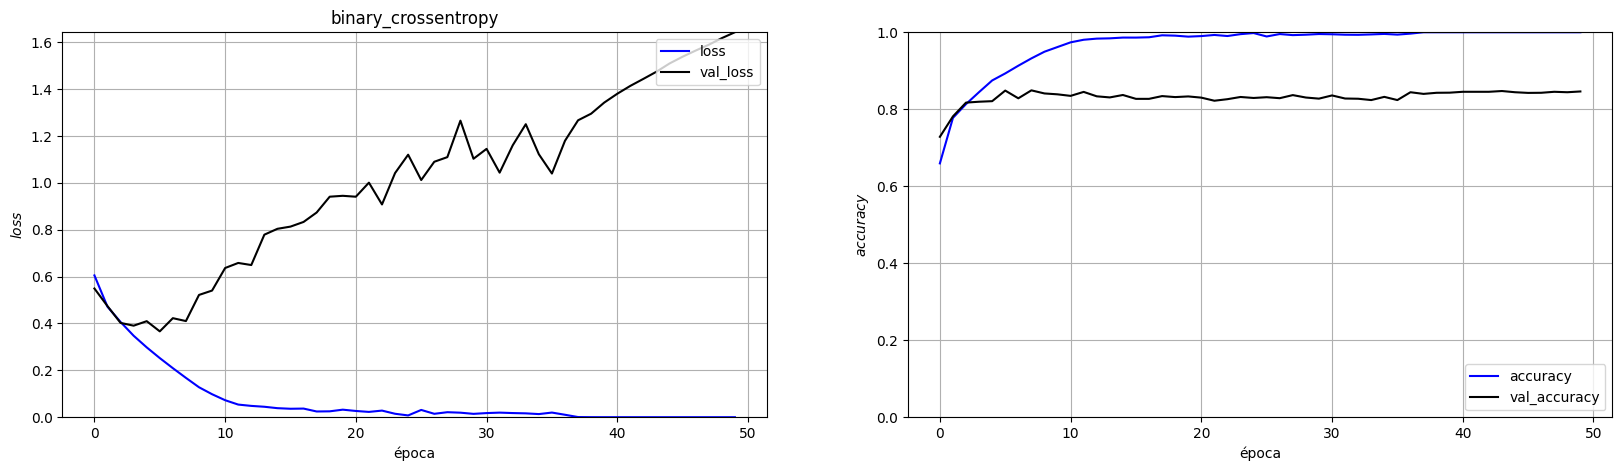

In [ ]:
plt.figure( figsize=(20,5))

plt.subplot(1,2,1)
plt.plot(history_CNN1.epoch, history_CNN1.history['loss'], 'b',label='loss')
plt.plot(history_CNN1.epoch, history_CNN1.history['val_loss'], 'k',label='val_loss')
plt.title(u'binary_crossentropy')
plt.xlabel(u'época')
plt.ylabel(r'$loss$')
plt.ylim(0, max(max(history_CNN1.history['loss']),max(history_CNN1.history['val_loss'])))
plt.grid()
plt.legend(loc='upper right')


plt.subplot(1,2,2)
plt.plot(history_CNN1.epoch, history_CNN1.history['accuracy'], 'b',label='accuracy')
plt.plot(history_CNN1.epoch, history_CNN1.history['val_accuracy'], 'k',label='val_accuracy')
#plt.title(u'binary_crossentropy')
plt.xlabel(u'época')
plt.ylabel(r'$accuracy$')
plt.ylim(0,1)
plt.grid()
plt.legend(loc='lower right')
plt.show()

In [ ]:
print(f'Tiempo de entrenamiento {(time.time() - t)/60:.5f} mins')

Tiempo de entrenamiento 298.26259 mins
